#### Vs30 Calculation and Plot
Author: Annora Vandanu Erlangga

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [85]:
filename = r"D:\Kulon Progo 2025\Seismik Pasif\processing\4_inversi\Report\vs_D1.dat"  # Ganti file
stat = os.path.splitext(os.path.basename(filename))[0].split('_')[-1]

with open(filename, "r") as file:
    for line in file:
        line = line.strip()  
        if "value=" in line:
            value = line.split("value=")[-1].strip()
            print(f"Nilai misfit: {value}")

Nilai misfit: 3.78118


In [86]:
# Membaca data dari file
def read_vs_data(filename):
    vs, depth = [], []
    with open(filename, 'r') as file:
        lines = file.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 2:
                try:
                    vs.append(float(parts[0]))
                    depth.append(float(parts[1]))
                except ValueError:
                    continue
    if depth:
        depth[-1] = 30.0
    return vs, depth

# Menghitung Vs30
def calculate_vs30(vs, depth):
    indices = [1, 3, 5, 7, 9]
    selected_vs = np.array([vs[i] for i in indices])
    selected_depth = np.array([depth[i] for i in indices])
    
    # Hitung ketebalan tiap lapisan
    thickness = np.array([selected_depth[i] - selected_depth[i-1] if i > 0 else selected_depth[i] for i in range(len(selected_depth))])

    # Hitung Vs30
    vs30 = np.sum(thickness) / np.sum(thickness / selected_vs)
    print(f"Vs30 for {stat}: {vs30:.4f} m/s")
    return vs30

Vs30 for D1: 253.0883 m/s


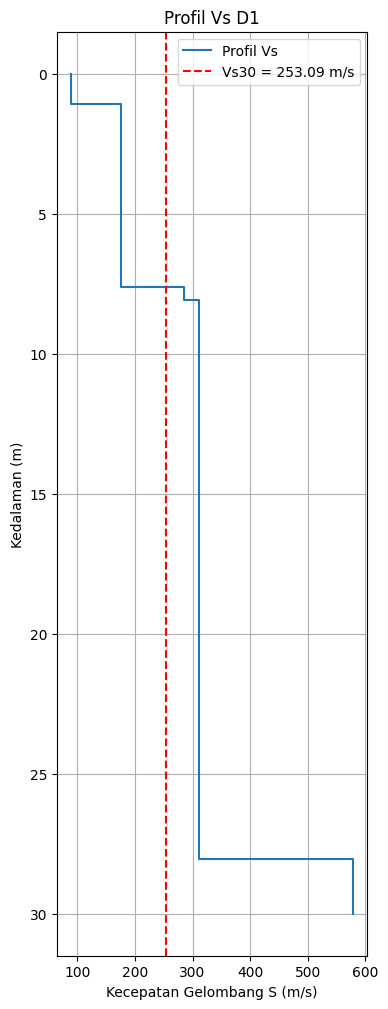

In [87]:
# Baca data dari file --- plot graph

vs, depth = read_vs_data(filename)
vs30 = calculate_vs30(vs, depth)

# Plot grafik
plt.figure(figsize=(4, 12))
plt.plot(vs, depth, linestyle='-', label="Profil Vs")
plt.axvline(x=vs30, color='r', linestyle='--', label=f"Vs30 = {vs30:.2f} m/s")
plt.gca().invert_yaxis()
#plt.xlim(0,1500)
plt.xlabel("Kecepatan Gelombang S (m/s)")
plt.ylabel("Kedalaman (m)")
plt.title(f"Profil Vs {stat}")
plt.legend()
plt.grid()
plt.show()